# NGFS Phase 5 Data Exploration

**Goal**: Understand the NGFS scenario data and identify variables that link climate scenarios to U.S. loan portfolios.

## Data Source Map

| Variable Category | Source File | Key Variables | Frequency | Years |
|---|---|---|---|---|
| **Macro-Financial** (GDP, unemployment, inflation, interest rates, equity/house prices) | `ngfs-phase5-nigem.xlsx` (NiGEM) | 160 variables per model/scenario | Annual | 2022–2050 |
| **Climate & Energy** (carbon prices, emissions, energy mix, temperature) | `ngfs-phase5-iam.xlsx` (IAM) | Thousands of variables | Annual (5-yr steps) | 2020–2100 |

**NiGEM structure**: Baseline scenario stores **level** values. All other scenarios store **differences from baseline** (% for quantities, absolute for rates). Must reconstruct levels as: `level = baseline × (1 + pct_diff/100)` or `level = baseline + abs_diff`.

**IAM structure**: All scenarios store levels directly. GDP damage estimates only available for REMIND model (not GCAM). GCAM provides `Policy Cost|GDP Loss` instead.

**Key gotcha**: Not all variable × scenario × model combinations exist. Always verify data is non-empty before plotting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 150
SAVE_DPI = 300
FIG_DIR = 'outputs/figures/'
DATA_DIR = 'data/raw/'

## 1. Load & Filter NiGEM Data (U.S. Only)

In [2]:
nigem_raw = pd.read_excel(f'{DATA_DIR}ngfs-phase5-nigem.xlsx', sheet_name='data')
nigem_us = nigem_raw[nigem_raw['Region'] == 'NiGEM NGFS v1.24.2|United States'].copy()

# Deduplicate (data has duplicate rows)
nigem_us = nigem_us.drop_duplicates(subset=['Model', 'Scenario', 'Variable'])

print(f'US NiGEM rows (deduplicated): {len(nigem_us)}')
print(f'Models: {nigem_us["Model"].nunique()}')
print(f'Scenarios: {sorted(nigem_us["Scenario"].unique())}')
print(f'Variables: {nigem_us["Variable"].nunique()}')

# Year columns (these are strings in the dataframe)
year_cols = [c for c in nigem_us.columns if isinstance(c, str) and c.isdigit()]
print(f'Year range: {year_cols[0]} - {year_cols[-1]}')

# Key insight: level variables only exist for Baseline; 
# other scenarios are stored as differences from baseline
gcam_model = 'NiGEM NGFS v1.24.2[GCAM 6.0 NGFS]'
gdp_check = nigem_us[(nigem_us['Variable'] == 'Gross Domestic Product (GDP)')]
print(f'\nGDP level scenarios: {sorted(gdp_check["Scenario"].unique())}')
gdp_diff_check = nigem_us[(nigem_us['Variable'] == 'Gross Domestic Product (GDP)(combined)')]
print(f'GDP diff scenarios: {sorted(gdp_diff_check["Scenario"].unique())}')

US NiGEM rows (deduplicated): 1824
Models: 3
Scenarios: ['Baseline', 'Below 2°C', 'Current Policies', 'Delayed transition', 'Fragmented World', 'Nationally Determined Contributions (NDCs)', 'Net Zero 2050']
Variables: 160
Year range: 2022 - 2050

GDP level scenarios: ['Baseline']
GDP diff scenarios: ['Below 2°C', 'Delayed transition', 'Fragmented World', 'Nationally Determined Contributions (NDCs)', 'Net Zero 2050']


In [3]:
# NiGEM structure: Baseline has LEVEL variables, other scenarios have DIFFERENCE variables
# We reconstruct levels for non-baseline scenarios: level = baseline * (1 + pct_diff/100)
# For absolute-difference variables (rates): level = baseline + abs_diff

# Variables we care about, with their diff counterpart and diff type
var_mapping = {
    'Gross Domestic Product (GDP)':       {'diff': 'Gross Domestic Product (GDP)(combined)',      'type': 'pct',  'label': 'GDP (2017 PPP $Bn)'},
    'Unemployment rate ; %':              {'diff': 'Unemployment rate ; %(combined)',              'type': 'abs',  'label': 'Unemployment Rate (%)'},
    'Inflation rate ; %':                 {'diff': 'Inflation rate ; %(combined)',                 'type': 'abs',  'label': 'Inflation Rate (%)'},
    'Central bank Intervention rate (policy interest rate) ; %': {'diff': 'Central bank Intervention rate (policy interest rate) ; %(combined)', 'type': 'abs', 'label': 'Policy Rate (%)'},
    'Long term interest rate ; %':        {'diff': 'Long term interest rate ; %(combined)',        'type': 'abs',  'label': 'Long-Term Rate (%)'},
    'Equity prices':                      {'diff': 'Equity prices(combined)',                      'type': 'pct',  'label': 'Equity Prices (2017=100)'},
    'House prices (residential)':         {'diff': 'House prices (residential)(combined)',         'type': 'pct',  'label': 'House Prices (2017=100)'},
    'Investment (private sector)':        {'diff': 'Investment (private sector)(combined)',        'type': 'pct',  'label': 'Private Investment ($Bn)'},
    'Carbon pricing ; $ per Tn CO2':      {'diff': 'Carbon pricing ; $ per Tn CO2(combined)',     'type': 'abs',  'label': 'Carbon Price ($/tCO2)'},
}

def reconstruct_levels(nigem_us, var_level, var_diff, diff_type, model, year_cols):
    """Reconstruct level paths for all scenarios from baseline + diffs."""
    # Get baseline level
    baseline = nigem_us[
        (nigem_us['Variable'] == var_level) &
        (nigem_us['Model'] == model) &
        (nigem_us['Scenario'] == 'Baseline')
    ]
    if baseline.empty:
        return pd.DataFrame()
    
    # Use .values to avoid index-type mismatch (year_cols are strings, index will be ints)
    base_vals = baseline.iloc[0][year_cols].astype(float).values
    int_index = [int(y) for y in year_cols]
    
    # Start with baseline
    result = pd.DataFrame({'Baseline': base_vals}, index=int_index)
    result.index.name = 'Year'
    
    # Get diffs for other scenarios
    diffs = nigem_us[
        (nigem_us['Variable'] == var_diff) &
        (nigem_us['Model'] == model)
    ]
    
    for _, row in diffs.iterrows():
        scenario = row['Scenario']
        diff_vals = row[year_cols].astype(float).values
        if diff_type == 'pct':
            result[scenario] = base_vals * (1 + diff_vals / 100)
        else:  # abs
            result[scenario] = base_vals + diff_vals
    
    return result

# Reconstruct all variables
nigem_levels = {}
for var_level, info in var_mapping.items():
    df = reconstruct_levels(nigem_us, var_level, info['diff'], info['type'], gcam_model, year_cols)
    if not df.empty:
        nigem_levels[info['label']] = df
        print(f"{info['label']:35s} | scenarios: {df.shape[1]} | years: {df.index[0]}-{df.index[-1]}")
    else:
        print(f"{info['label']:35s} | NOT FOUND")

GDP (2017 PPP $Bn)                  | scenarios: 6 | years: 2022-2050
Unemployment Rate (%)               | scenarios: 6 | years: 2022-2050
Inflation Rate (%)                  | scenarios: 6 | years: 2022-2050
Policy Rate (%)                     | scenarios: 6 | years: 2022-2050
Long-Term Rate (%)                  | scenarios: 6 | years: 2022-2050
Equity Prices (2017=100)            | scenarios: 6 | years: 2022-2050
House Prices (2017=100)             | scenarios: 6 | years: 2022-2050
Private Investment ($Bn)            | scenarios: 6 | years: 2022-2050
Carbon Price ($/tCO2)               | scenarios: 6 | years: 2022-2050


In [4]:
# Verify reconstruction worked
print('Reconstructed level variables:')
for label, df in nigem_levels.items():
    print(f"\n{label}:")
    for scen in df.columns:
        print(f"  {scen:45s} | 2025: {df.loc[2025, scen]:>10.1f} | 2030: {df.loc[2030, scen]:>10.1f} | 2050: {df.loc[2050, scen]:>10.1f}")

Reconstructed level variables:

GDP (2017 PPP $Bn):
  Baseline                                      | 2025:    23253.3 | 2030:    25481.1 | 2050:    33751.5
  Delayed transition                            | 2025:    22808.2 | 2030:    24620.3 | 2050:    30573.4
  Fragmented World                              | 2025:    22801.7 | 2030:    24622.1 | 2050:    30300.0
  Nationally Determined Contributions (NDCs)    | 2025:    22704.5 | 2030:    24454.9 | 2050:    30374.0
  Net Zero 2050                                 | 2025:    22572.8 | 2030:    24169.0 | 2050:    31460.2
  Below 2°C                                     | 2025:    22622.5 | 2030:    24269.6 | 2050:    31208.9

Unemployment Rate (%):
  Baseline                                      | 2025:        3.8 | 2030:        4.4 | 2050:        4.7
  Delayed transition                            | 2025:        3.8 | 2030:        4.3 | 2050:        4.6
  Fragmented World                              | 2025:        3.8 | 2030:        4.

## 2. Scenario Comparison — Key Macro Variables

These plots show how the 7 NGFS scenarios produce **different macro-financial paths** for the U.S. — the divergence between scenarios is what drives differential loan portfolio outcomes.

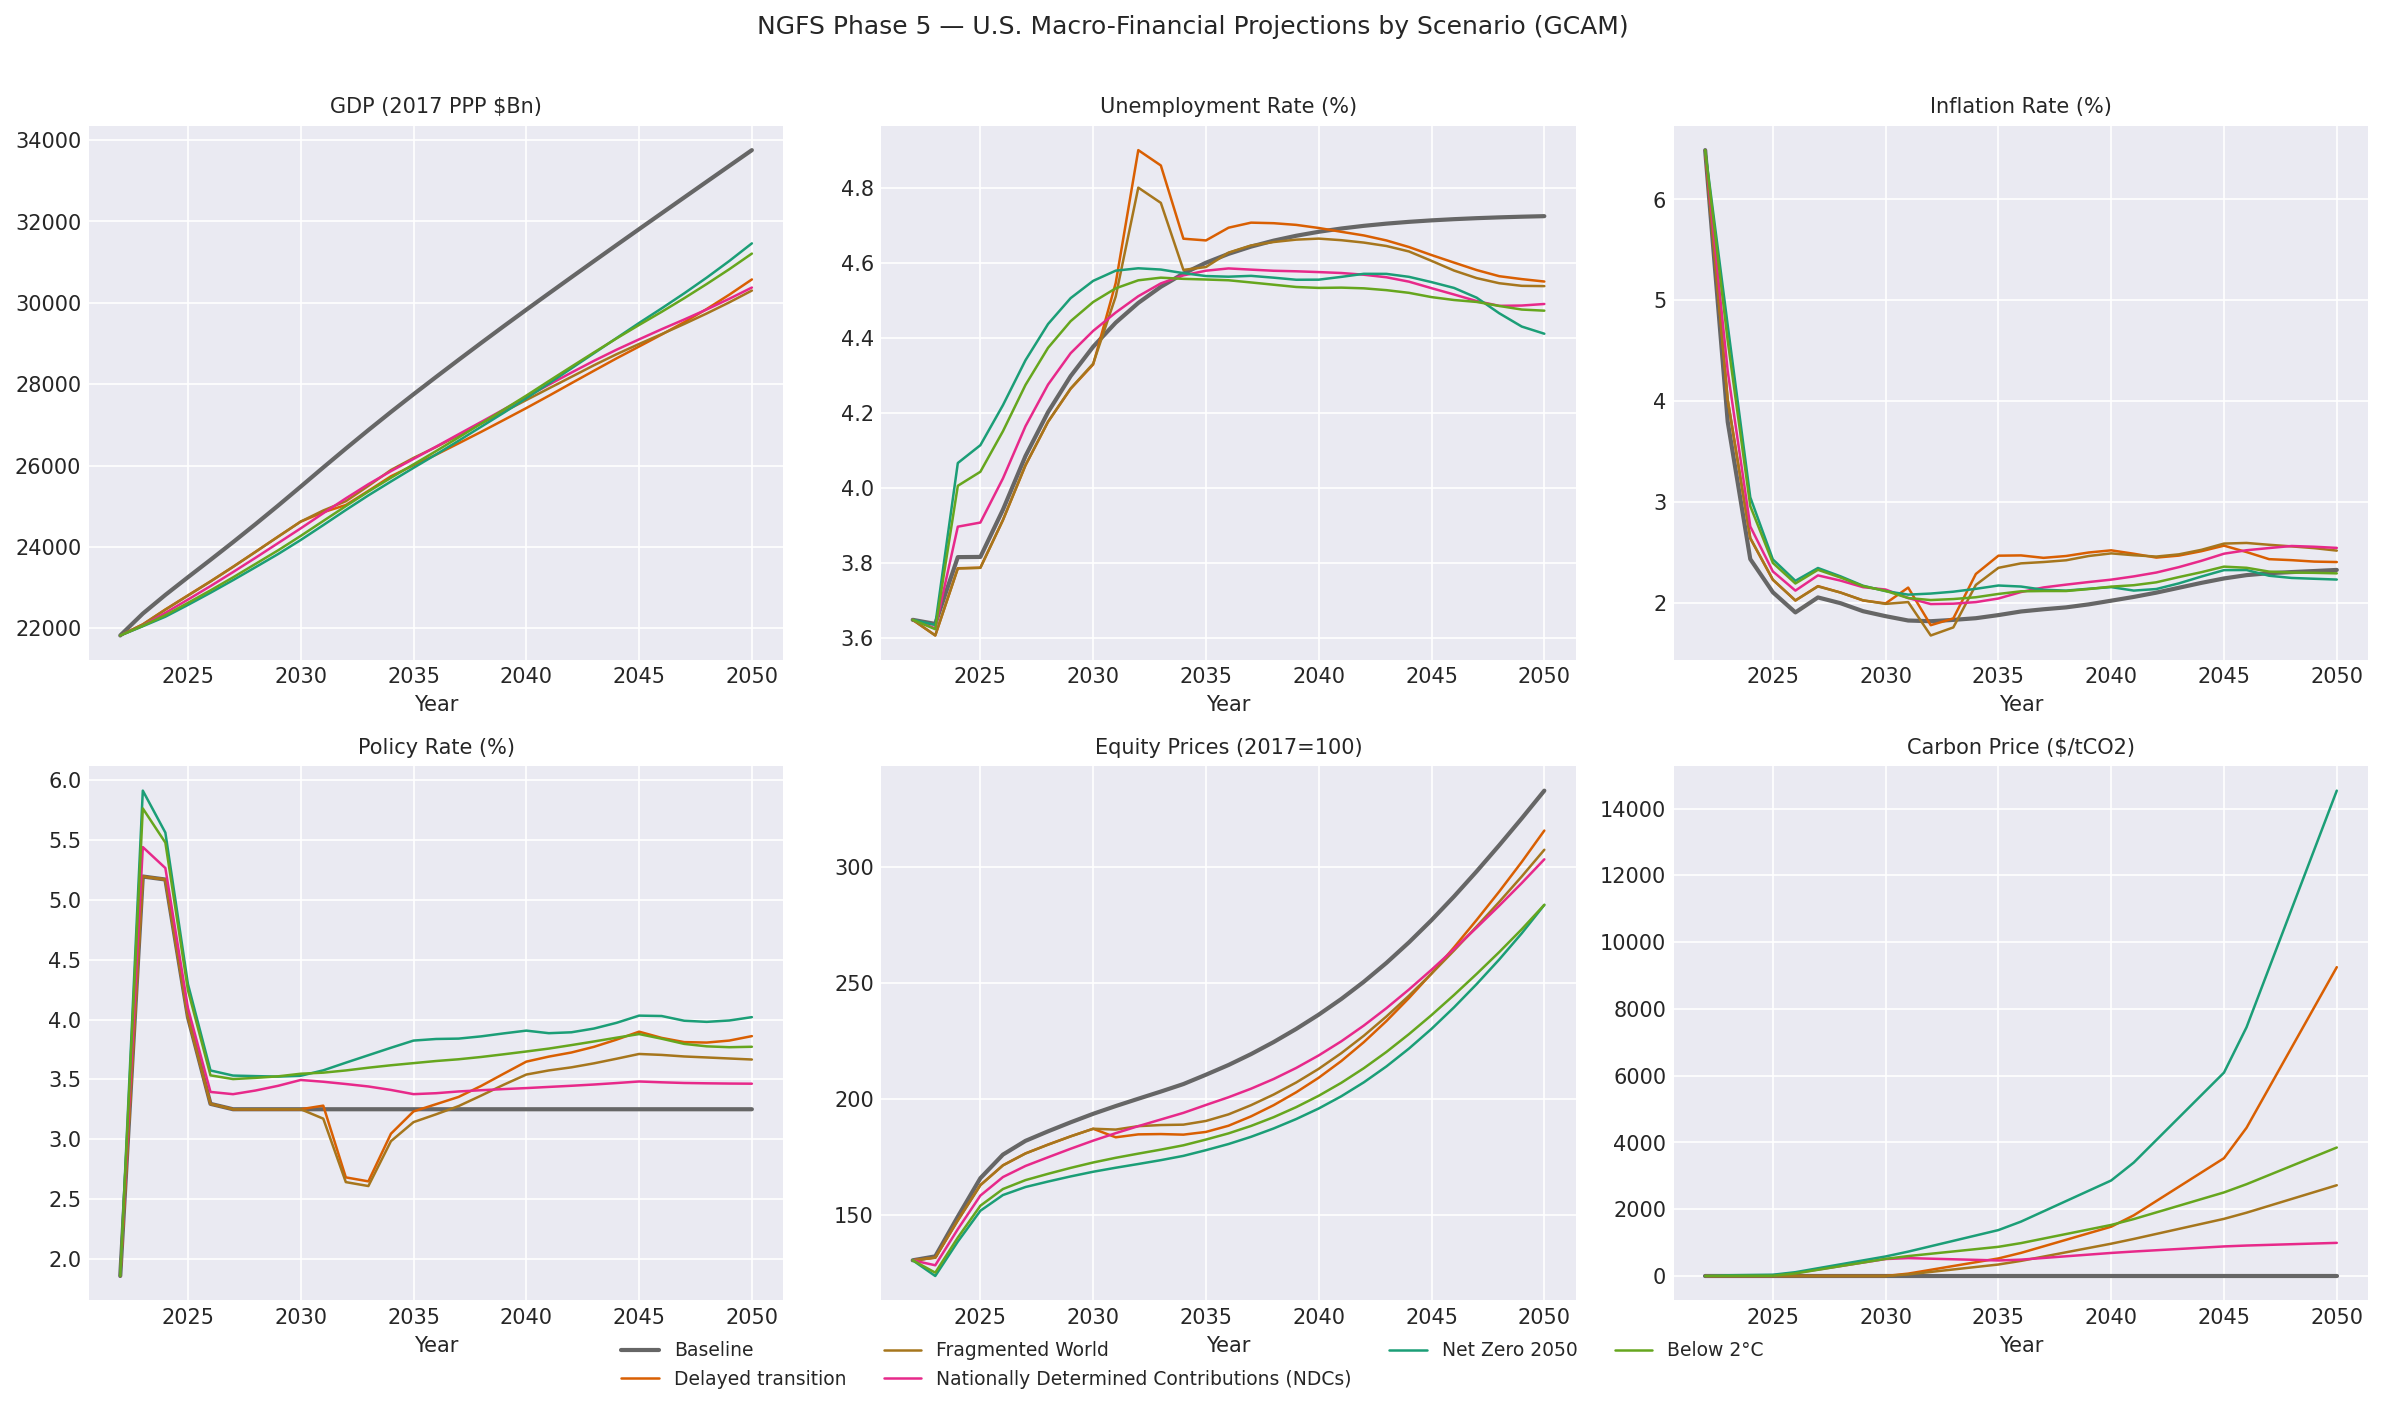

Saved: outputs/figures/ngfs_scenario_paths.png — 6 panels, all with data


In [5]:
# Color scheme for NGFS scenarios
scenario_colors = {
    'Net Zero 2050': '#1b9e77',
    'Below 2°C': '#66a61e',
    'Low demand': '#7570b3',
    'Delayed transition': '#d95f02',
    'Nationally Determined Contributions (NDCs)': '#e7298a',
    'Fragmented World': '#a6761d',
    'Current Policies': '#e6ab02',
    'Baseline': '#666666',
}

# Plot the 6 most important variables — reconstructed levels
plot_vars = [
    'GDP (2017 PPP $Bn)', 'Unemployment Rate (%)', 'Inflation Rate (%)',
    'Policy Rate (%)', 'Equity Prices (2017=100)', 'Carbon Price ($/tCO2)'
]

# Validation: check all requested variables exist
for v in plot_vars:
    if v not in nigem_levels:
        print(f"WARNING: '{v}' not in nigem_levels — panel will be empty")
    else:
        df = nigem_levels[v]
        assert not df.empty, f"'{v}' DataFrame is empty"
        assert not df.isna().all().all(), f"'{v}' DataFrame is all NaN"

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, var_label in zip(axes.flat, plot_vars):
    if var_label not in nigem_levels:
        ax.text(0.5, 0.5, f'{var_label}\nNOT IN DATA', ha='center', va='center',
                transform=ax.transAxes, fontsize=11, color='red')
        ax.set_title(var_label, fontsize=10, color='red')
        continue
    df = nigem_levels[var_label]
    for scenario in df.columns:
        color = scenario_colors.get(scenario, 'gray')
        lw = 2 if scenario == 'Baseline' else 1.2
        ax.plot(df.index, df[scenario], label=scenario, color=color, linewidth=lw)
    ax.set_title(var_label, fontsize=10)
    ax.set_xlabel('Year')

# Single legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('NGFS Phase 5 — U.S. Macro-Financial Projections by Scenario (GCAM)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}ngfs_scenario_paths.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}ngfs_scenario_paths.png — {len(plot_vars)} panels, all with data')

## 3. Scenario Divergence from Baseline

The "combined" (or difference) variables show % deviations from the baseline — this is often more useful for modeling because it isolates the **marginal climate impact**.

In [6]:
# Extract % difference variables for key series
diff_vars = {
    'Gross Domestic Product (GDP)(combined)': 'GDP (% diff from baseline)',
    'Unemployment rate ; %(combined)': 'Unemployment (abs. diff, pp)',
    'Inflation rate ; %(combined)': 'Inflation (abs. diff, pp)',
    'Central bank Intervention rate (policy interest rate) ; %(combined)': 'Policy Rate (abs. diff, pp)',
    'Long term interest rate ; %(combined)': 'Long-Term Rate (abs. diff, pp)',
    'Equity prices(combined)': 'Equity Prices (% diff)',
    'House prices (residential)(combined)': 'House Prices (% diff)',
    'Investment (private sector)(combined)': 'Private Investment (% diff)',
}

diff_pivoted = {}
for var_name, label in diff_vars.items():
    sub = nigem_us[
        (nigem_us['Variable'] == var_name) &
        (nigem_us['Model'] == gcam_model)
    ]
    if not sub.empty:
        piv = sub[['Scenario'] + year_cols].set_index('Scenario').T
        piv.index = piv.index.astype(int)
        piv.index.name = 'Year'
        diff_pivoted[label] = piv

print(f'Difference variables available ({len(diff_pivoted)}):')
for label, df in diff_pivoted.items():
    print(f'  {label:40s} | scenarios: {df.shape[1]} | years: {df.index[0]}-{df.index[-1]}')

Difference variables available (8):
  GDP (% diff from baseline)               | scenarios: 5 | years: 2022-2050
  Unemployment (abs. diff, pp)             | scenarios: 5 | years: 2022-2050
  Inflation (abs. diff, pp)                | scenarios: 5 | years: 2022-2050
  Policy Rate (abs. diff, pp)              | scenarios: 5 | years: 2022-2050
  Long-Term Rate (abs. diff, pp)           | scenarios: 5 | years: 2022-2050
  Equity Prices (% diff)                   | scenarios: 5 | years: 2022-2050
  House Prices (% diff)                    | scenarios: 5 | years: 2022-2050
  Private Investment (% diff)              | scenarios: 5 | years: 2022-2050


All 6 difference variables available


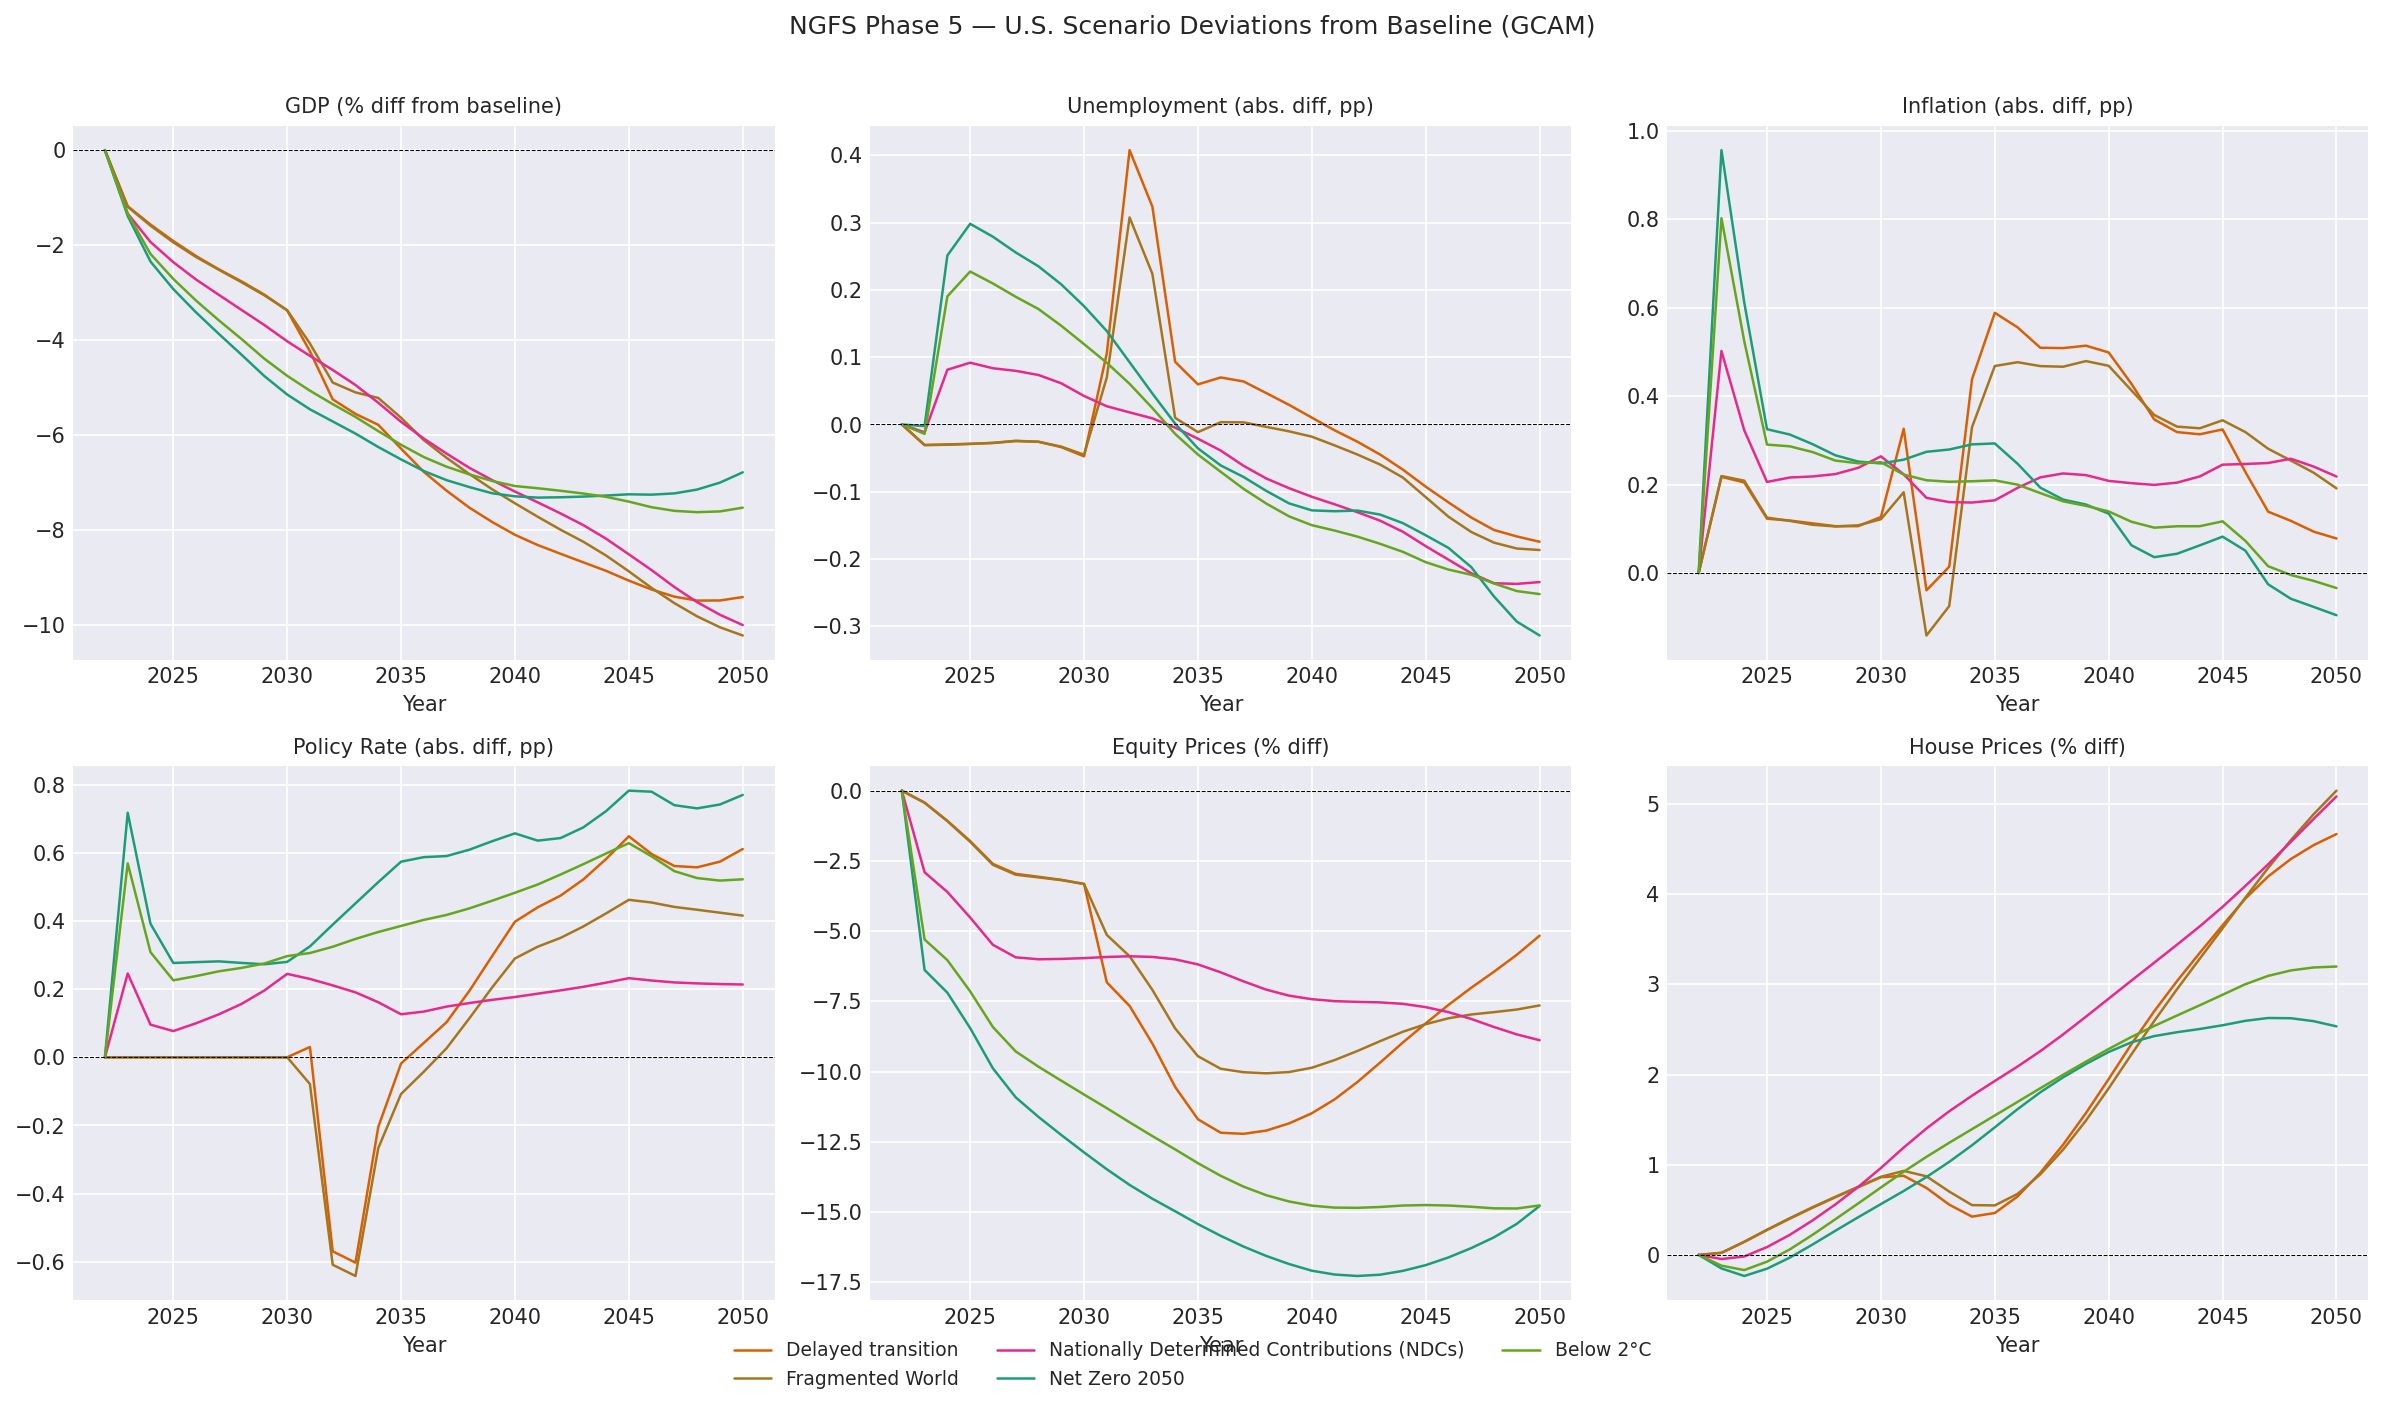

Saved: outputs/figures/ngfs_scenario_diffs.png


In [7]:
# Plot divergence from baseline
plot_diffs = [
    'GDP (% diff from baseline)', 'Unemployment (abs. diff, pp)',
    'Inflation (abs. diff, pp)', 'Policy Rate (abs. diff, pp)',
    'Equity Prices (% diff)', 'House Prices (% diff)'
]

# Validation
missing = [v for v in plot_diffs if v not in diff_pivoted]
if missing:
    print(f"WARNING: {len(missing)} variables missing from diff_pivoted: {missing}")
else:
    print(f"All {len(plot_diffs)} difference variables available")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, var_label in zip(axes.flat, plot_diffs):
    if var_label not in diff_pivoted:
        ax.text(0.5, 0.5, f'{var_label}\nNOT IN DATA', ha='center', va='center',
                transform=ax.transAxes, fontsize=11, color='red')
        ax.set_title(var_label, fontsize=10, color='red')
        continue
    df = diff_pivoted[var_label]
    plotted = 0
    for scenario in df.columns:
        if scenario == 'Baseline':
            continue
        color = scenario_colors.get(scenario, 'gray')
        ax.plot(df.index, df[scenario], label=scenario, color=color, linewidth=1.2)
        plotted += 1
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(var_label, fontsize=10)
    ax.set_xlabel('Year')
    if plotted == 0:
        ax.text(0.5, 0.5, 'No scenario data', ha='center', va='center',
                transform=ax.transAxes, color='red')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('NGFS Phase 5 — U.S. Scenario Deviations from Baseline (GCAM)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}ngfs_scenario_diffs.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}ngfs_scenario_diffs.png')

## 4. Model Uncertainty — Same Scenario, Different IAMs

A key insight from Jung et al. (SR 1058) is that different GE models produce meaningfully different results. Let's see how the 3 NiGEM model variants compare.

Left panel: 3 models plotted
Right panel: 6 lines plotted


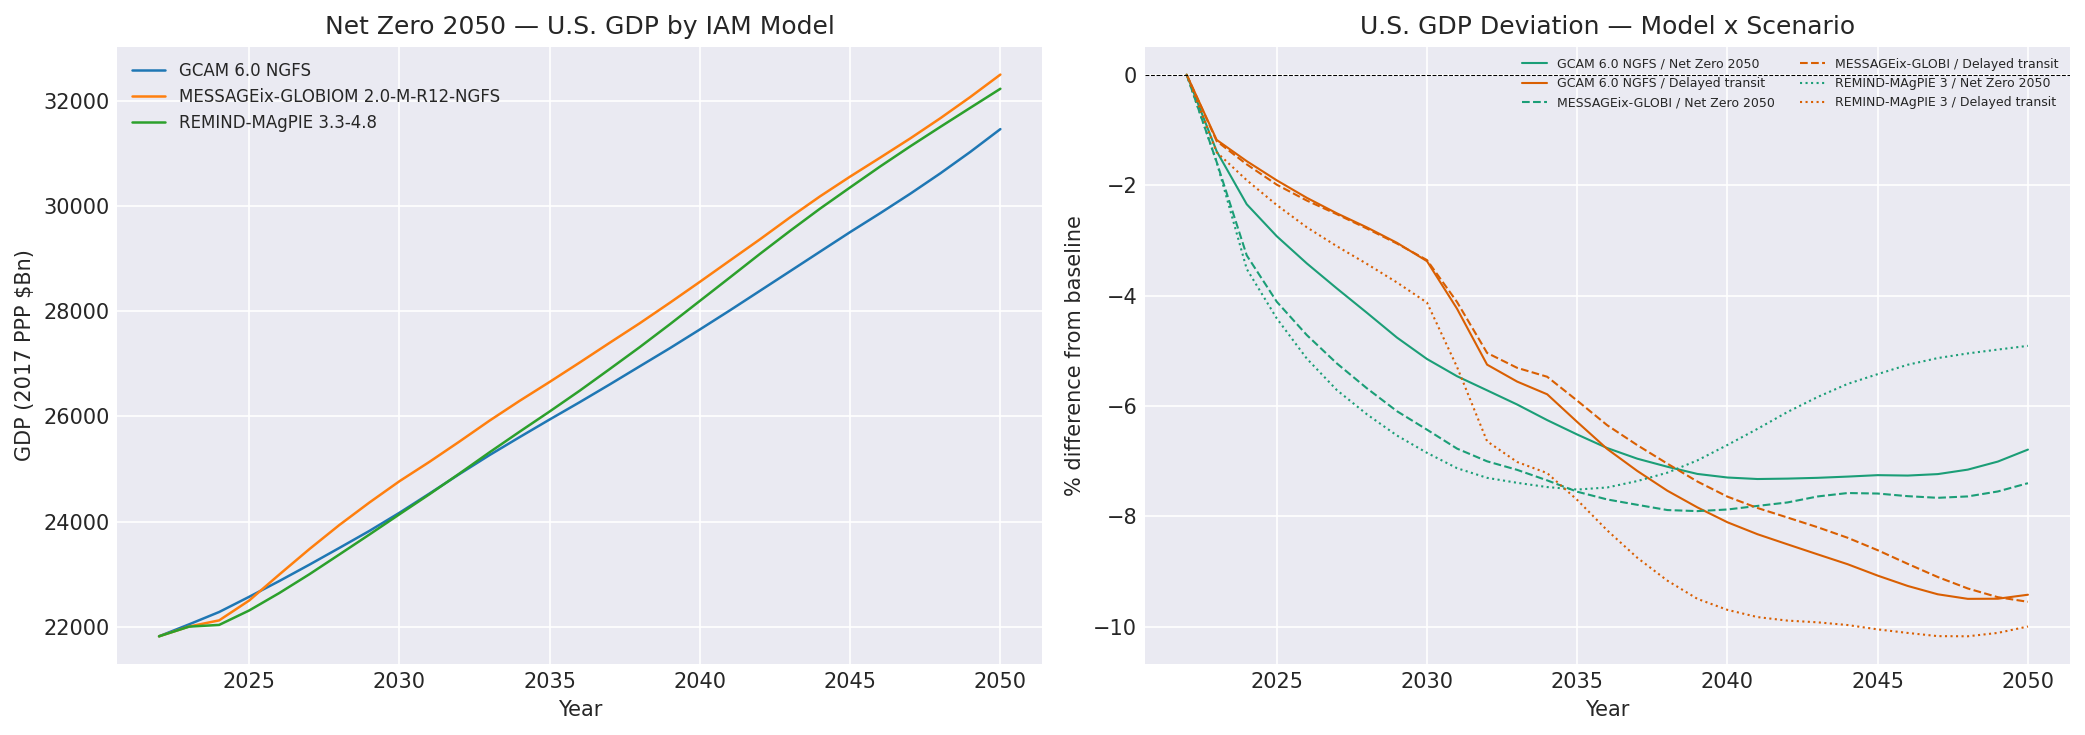

Saved: outputs/figures/ngfs_model_uncertainty.png


In [8]:
# Compare models for a single scenario (Net Zero 2050) on GDP
# NiGEM stores GDP levels ONLY for Baseline — other scenarios are % diffs.
# We reconstruct Net Zero 2050 GDP levels per model: baseline * (1 + pct_diff/100)

gdp_level_var = 'Gross Domestic Product (GDP)'
gdp_diff_var = 'Gross Domestic Product (GDP)(combined)'
models = sorted(nigem_us['Model'].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: Reconstructed GDP levels under Net Zero 2050, by model
ax = axes[0]
plotted = 0
for model in models:
    model_short = model.split('[')[1].rstrip(']') if '[' in model else model

    # Get this model's baseline GDP level
    baseline = nigem_us[
        (nigem_us['Variable'] == gdp_level_var) &
        (nigem_us['Model'] == model) &
        (nigem_us['Scenario'] == 'Baseline')
    ]
    # Get this model's Net Zero 2050 % diff
    diff = nigem_us[
        (nigem_us['Variable'] == gdp_diff_var) &
        (nigem_us['Model'] == model) &
        (nigem_us['Scenario'] == 'Net Zero 2050')
    ]
    if baseline.empty or diff.empty:
        print(f"  INFO: Skipping {model_short} — baseline empty={baseline.empty}, diff empty={diff.empty}")
        continue

    base_vals = baseline.iloc[0][year_cols].astype(float).values
    diff_vals = diff.iloc[0][year_cols].astype(float).values
    nz50_levels = base_vals * (1 + diff_vals / 100)

    ax.plot([int(c) for c in year_cols], nz50_levels, label=model_short, linewidth=1.2)
    plotted += 1

if plotted == 0:
    ax.text(0.5, 0.5, 'No GDP level data\navailable for reconstruction',
            ha='center', va='center', transform=ax.transAxes, fontsize=11, color='red')
    print("WARNING: Left panel has no data — no model had both baseline + diff")
else:
    ax.legend(fontsize=8)
    print(f"Left panel: {plotted} models plotted")
ax.set_title('Net Zero 2050 — U.S. GDP by IAM Model')
ax.set_ylabel('GDP (2017 PPP $Bn)')
ax.set_xlabel('Year')

# Right panel: GDP % diff from baseline — all 3 models x 3 key scenarios
ax = axes[1]
line_styles = ['-', '--', ':']
key_scenarios = ['Net Zero 2050', 'Delayed transition', 'Current Policies']
plotted = 0

for model, ls in zip(models, line_styles):
    model_short = model.split('[')[1].rstrip(']') if '[' in model else model
    for scenario in key_scenarios:
        sub = nigem_us[
            (nigem_us['Variable'] == gdp_diff_var) &
            (nigem_us['Model'] == model) &
            (nigem_us['Scenario'] == scenario)
        ]
        if sub.empty:
            continue
        vals = sub.iloc[0][year_cols].astype(float).values
        color = scenario_colors.get(scenario, 'gray')
        label = f'{model_short[:15]} / {scenario[:15]}'
        ax.plot([int(c) for c in year_cols], vals, label=label, color=color,
                linestyle=ls, linewidth=1)
        plotted += 1

ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('U.S. GDP Deviation — Model x Scenario')
ax.set_ylabel('% difference from baseline')
ax.set_xlabel('Year')
ax.legend(fontsize=6, ncol=2)

if plotted == 0:
    ax.text(0.5, 0.5, 'No deviation data', ha='center', va='center',
            transform=ax.transAxes, fontsize=11, color='red')
    print("WARNING: Right panel has no data")
else:
    print(f"Right panel: {plotted} lines plotted")

plt.tight_layout()
plt.savefig(f'{FIG_DIR}ngfs_model_uncertainty.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}ngfs_model_uncertainty.png')

## 5. IAM Data — Carbon Prices & Emissions (U.S.)

In [9]:
iam_raw = pd.read_excel(f'{DATA_DIR}ngfs-phase5-iam.xlsx', sheet_name='data')

# US regions vary by model
us_regions = ['GCAM 6.0 NGFS|USA', 'REMIND-MAgPIE 3.2-4.6|United States of America']
iam_us = iam_raw[iam_raw['Region'].isin(us_regions)].copy()

iam_year_cols = [c for c in iam_us.columns if str(c).isdigit()]
print(f'US IAM rows: {len(iam_us)}')
print(f'Year range: {iam_year_cols[0]} - {iam_year_cols[-1]}')

# Carbon price by scenario (GCAM model, USA)
carbon = iam_us[
    (iam_us['Variable'] == 'Price|Carbon') &
    (iam_us['Region'] == 'GCAM 6.0 NGFS|USA')
].copy()

# CO2 emissions by scenario
emissions = iam_us[
    (iam_us['Variable'] == 'Emissions|CO2') &
    (iam_us['Region'] == 'GCAM 6.0 NGFS|USA')
].copy()

# GDP with damage
gdp_damage = iam_us[
    (iam_us['Variable'] == 'GDP|MER|including medium chronic physical risk damage estimate') &
    (iam_us['Region'] == 'GCAM 6.0 NGFS|USA')
].copy()

print(f'\nCarbon price scenarios: {sorted(carbon["Scenario"].unique())}')
print(f'Emissions scenarios: {sorted(emissions["Scenario"].unique())}')
print(f'GDP damage scenarios: {sorted(gdp_damage["Scenario"].unique())}')

US IAM rows: 17584
Year range: 2020 - 2100

Carbon price scenarios: ['Below 2°C', 'Current Policies', 'Delayed transition', 'Fragmented World', 'Low demand', 'Nationally Determined Contributions (NDCs)', 'Net Zero 2050']
Emissions scenarios: ['Below 2°C', 'Current Policies', 'Delayed transition', 'Fragmented World', 'Low demand', 'Nationally Determined Contributions (NDCs)', 'Net Zero 2050']
GDP damage scenarios: []


GDP damage (REMIND): 7 scenarios


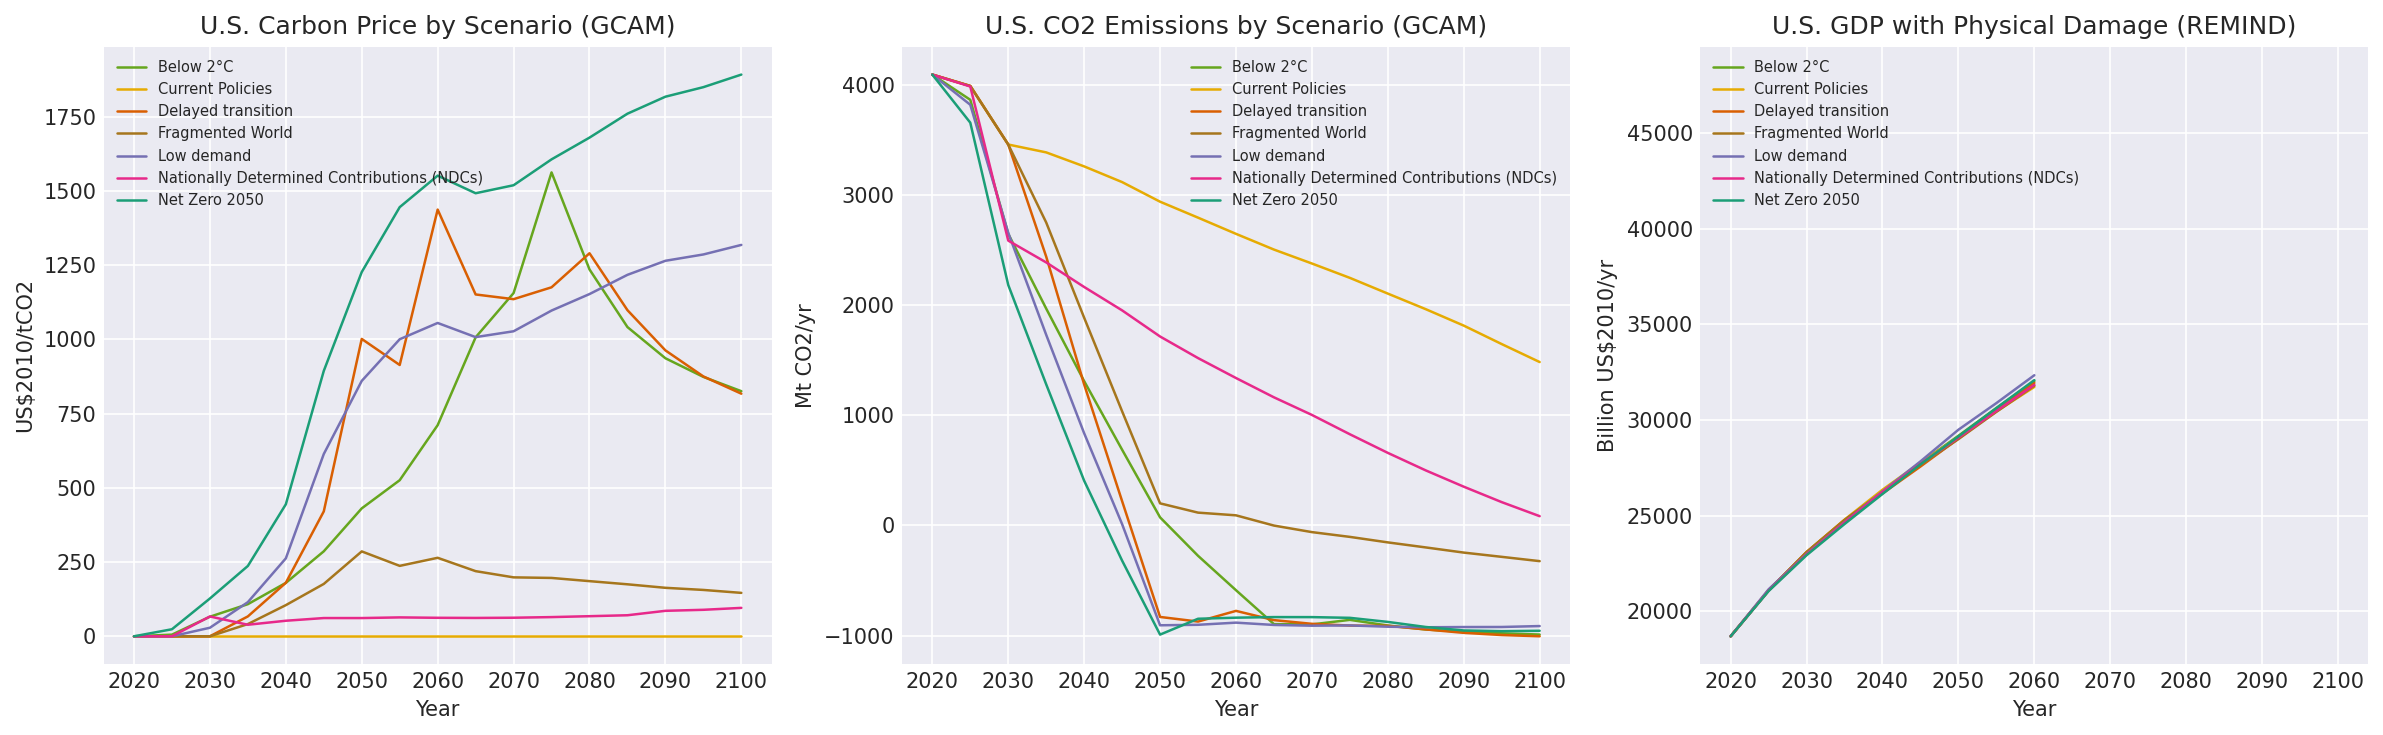

Saved: outputs/figures/ngfs_iam_us.png


In [10]:
# GDP damage estimate is only available for REMIND, not GCAM.
# For GCAM USA, we use Policy Cost|GDP Loss instead.
# Always validate before plotting.

remind_us = 'REMIND-MAgPIE 3.2-4.6|United States of America'
gcam_us = 'GCAM 6.0 NGFS|USA'

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Carbon Price (IAM, GCAM USA)
ax = axes[0]
if carbon.empty:
    ax.text(0.5, 0.5, 'Carbon Price\nNO DATA', ha='center', va='center',
            transform=ax.transAxes, fontsize=12, color='red')
    print("WARNING: carbon DataFrame is empty — skipping panel")
else:
    for _, row in carbon.iterrows():
        vals = [row[c] for c in iam_year_cols]
        color = scenario_colors.get(row['Scenario'], 'gray')
        ax.plot([int(c) for c in iam_year_cols], vals, label=row['Scenario'],
                color=color, linewidth=1.2)
    ax.set_ylabel('US$2010/tCO2')
    ax.legend(fontsize=7)
ax.set_title('U.S. Carbon Price by Scenario (GCAM)')
ax.set_xlabel('Year')

# Panel 2: CO2 Emissions (IAM, GCAM USA)
ax = axes[1]
if emissions.empty:
    ax.text(0.5, 0.5, 'CO2 Emissions\nNO DATA', ha='center', va='center',
            transform=ax.transAxes, fontsize=12, color='red')
    print("WARNING: emissions DataFrame is empty — skipping panel")
else:
    for _, row in emissions.iterrows():
        vals = [row[c] for c in iam_year_cols]
        color = scenario_colors.get(row['Scenario'], 'gray')
        ax.plot([int(c) for c in iam_year_cols], vals, label=row['Scenario'],
                color=color, linewidth=1.2)
    ax.set_ylabel('Mt CO2/yr')
    ax.legend(fontsize=7)
ax.set_title('U.S. CO2 Emissions by Scenario (GCAM)')
ax.set_xlabel('Year')

# Panel 3: GDP with Physical Damage — use REMIND (GCAM doesn't have this variable)
gdp_damage_remind = iam_us[
    (iam_us['Variable'] == 'GDP|MER|including medium chronic physical risk damage estimate') &
    (iam_us['Region'] == remind_us)
].copy()

# Also get counterfactual (no damage) for comparison
gdp_nodamage_remind = iam_us[
    (iam_us['Variable'] == 'GDP|MER|Counterfactual without damage') &
    (iam_us['Region'] == remind_us)
].copy()

ax = axes[2]
if gdp_damage_remind.empty:
    ax.text(0.5, 0.5, 'GDP Damage\nNO DATA (REMIND)', ha='center', va='center',
            transform=ax.transAxes, fontsize=12, color='red')
    print("WARNING: GDP damage (REMIND) is empty — skipping panel")
else:
    print(f"GDP damage (REMIND): {len(gdp_damage_remind)} scenarios")
    for _, row in gdp_damage_remind.iterrows():
        vals = [row[c] for c in iam_year_cols]
        color = scenario_colors.get(row['Scenario'], 'gray')
        ax.plot([int(c) for c in iam_year_cols], vals, label=row['Scenario'],
                color=color, linewidth=1.2)
    ax.set_ylabel('Billion US$2010/yr')
    ax.legend(fontsize=7)
ax.set_title('U.S. GDP with Physical Damage (REMIND)')
ax.set_xlabel('Year')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}ngfs_iam_us.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}ngfs_iam_us.png')

## 6. Mapping NGFS → FRED: The Bridge for Modeling

The key modeling insight is that NiGEM provides **scenario-conditional macro paths** for the same variables we have historical FRED data for. This creates a natural two-step approach:

| NGFS NiGEM Variable | FRED Equivalent | Mapping |
|---|---|---|
| GDP (2017 PPP $Bn) | GDPC1 | Scale/level adjustment |
| Unemployment rate (%) | UNRATE | Direct |
| Inflation rate (%) | CPI growth | Direct (concept match) |
| Policy rate (%) | FEDFUNDS | Direct |
| Long-term rate (%) | DGS10 | Direct |

**Modeling strategy**: 
1. Estimate VAR/ADL on **historical FRED data** (monthly) linking loan growth to macro variables  
2. Feed **NGFS NiGEM annual paths** as future macro variable scenarios  
3. Generate **conditional loan growth forecasts** under each climate scenario  

The frequency mismatch (NGFS annual vs. FRED monthly) can be handled by:
- Aggregating FRED to annual for estimation
- OR interpolating NGFS to monthly/quarterly (linear or cubic spline)

In [11]:
# Summary table: scenario endpoints at 2030, 2040, 2050 using reconstructed levels
horizon_years = [2030, 2040, 2050]
key_scenarios_display = ['Baseline', 'Net Zero 2050', 'Below 2°C', 'Delayed transition',
                         'Nationally Determined Contributions (NDCs)', 'Fragmented World']

summary_vars = ['GDP (2017 PPP $Bn)', 'Unemployment Rate (%)', 'Policy Rate (%)',
                'Equity Prices (2017=100)', 'House Prices (2017=100)']

for var_label in summary_vars:
    if var_label not in nigem_levels:
        continue
    df = nigem_levels[var_label]
    print(f'\n=== {var_label} ===')
    for scen in key_scenarios_display:
        if scen in df.columns:
            vals = [f'{df.loc[y, scen]:>10.2f}' for y in horizon_years]
            print(f'  {scen:50s} | 2030: {vals[0]} | 2040: {vals[1]} | 2050: {vals[2]}')


=== GDP (2017 PPP $Bn) ===
  Baseline                                           | 2030:   25481.08 | 2040:   29828.92 | 2050:   33751.51
  Net Zero 2050                                      | 2030:   24169.04 | 2040:   27653.12 | 2050:   31460.18
  Below 2°C                                          | 2030:   24269.61 | 2040:   27717.80 | 2050:   31208.94
  Delayed transition                                 | 2030:   24620.35 | 2040:   27411.35 | 2050:   30573.40
  Nationally Determined Contributions (NDCs)         | 2030:   24454.91 | 2040:   27682.97 | 2050:   30373.97
  Fragmented World                                   | 2030:   24622.09 | 2040:   27609.34 | 2050:   30299.96

=== Unemployment Rate (%) ===
  Baseline                                           | 2030:       4.38 | 2040:       4.68 | 2050:       4.73
  Net Zero 2050                                      | 2030:       4.55 | 2040:       4.56 | 2050:       4.41
  Below 2°C                                          | 2030: 

## 7. Transition vs. Physical Risk Decomposition

The NiGEM data distinguishes between *transition* and *physical* risk impacts. This is exactly the decomposition BofA cares about.

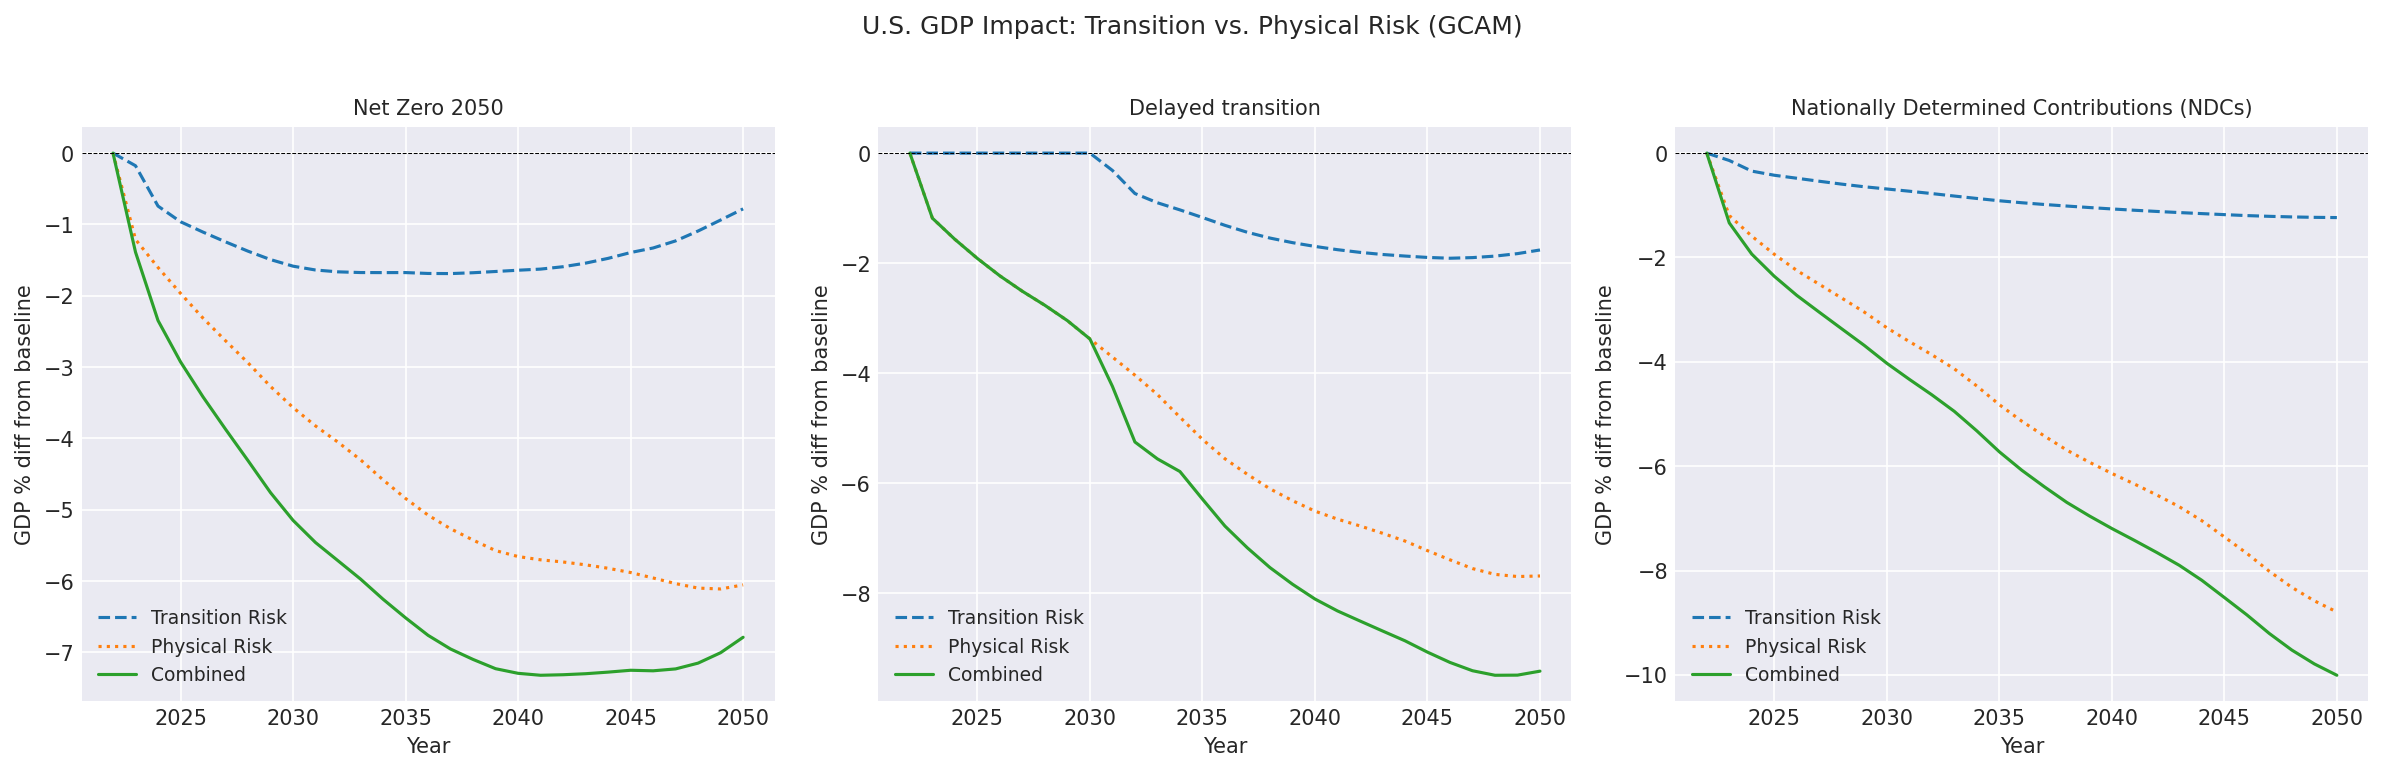

Saved: outputs/figures/ngfs_risk_decomposition.png


In [12]:
# GDP impact decomposition: transition vs physical vs combined
# Note: Current Policies only has (physical) in NiGEM — no transition policy in that scenario.
# We use NDCs instead, which has all three components.
decomp_vars = {
    'Gross Domestic Product (GDP)(transition)': 'Transition Risk',
    'Gross Domestic Product (GDP)(physical)': 'Physical Risk',
    'Gross Domestic Product (GDP)(combined)': 'Combined',
}

decomp_scenarios = ['Net Zero 2050', 'Delayed transition', 'Nationally Determined Contributions (NDCs)']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, scenario in zip(axes, decomp_scenarios):
    plotted = 0
    for var_name, label in decomp_vars.items():
        sub = nigem_us[
            (nigem_us['Variable'] == var_name) &
            (nigem_us['Model'] == gcam_model) &
            (nigem_us['Scenario'] == scenario)
        ]
        if sub.empty:
            print(f"  INFO: {label} not available for {scenario} — skipping line")
            continue
        vals = [sub.iloc[0][c] for c in year_cols]
        ls = '-' if label == 'Combined' else ('--' if label == 'Transition Risk' else ':')
        ax.plot([int(c) for c in year_cols], vals, label=label, linewidth=1.5, linestyle=ls)
        plotted += 1
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(f'{scenario}', fontsize=10)
    ax.set_ylabel('GDP % diff from baseline')
    ax.set_xlabel('Year')
    if plotted > 0:
        ax.legend(fontsize=9)
    else:
        ax.text(0.5, 0.5, 'NO DECOMPOSITION DATA', ha='center', va='center',
                transform=ax.transAxes, fontsize=11, color='red')
        print(f"WARNING: No decomposition data for {scenario}")

fig.suptitle('U.S. GDP Impact: Transition vs. Physical Risk (GCAM)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}ngfs_risk_decomposition.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR}ngfs_risk_decomposition.png')

## 8. Summary & Implications for Loan Modeling

### What the NGFS data tells us

1. **NiGEM is the bridge** — it translates climate scenarios into macro-financial variables (GDP, unemployment, interest rates) that we can link to historical FRED loan data

2. **7 scenarios span the risk space**:
   - **Orderly** (Net Zero 2050, Below 2C, Low Demand): gradual transition, modest macro impact
   - **Disorderly** (Delayed Transition, Fragmented World): abrupt policy, larger GDP/unemployment shocks
   - **Hot House** (NDCs, Current Policies): worst physical damage long-run, minimal transition cost short-run

3. **Frequency**: NGFS is annual (2022-2050); our FRED loan data is monthly. Decision needed: aggregate to annual or interpolate.

4. **Model uncertainty matters** — 3 IAM families produce different paths for the same scenario

5. **Risk decomposition available** — transition vs. physical impact on every variable, useful for BofA narrative

### Next Steps
- Build the VAR/ADL model on historical FRED data (annual or quarterly)
- Use NiGEM scenario paths as conditional forecasts
- Compare loan growth outcomes across scenarios
- Present model uncertainty (across IAM families) as confidence bands